In [ ]:
!pip install deepface opencv-python matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 49.3 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from deepface import DeepFace

26-06-17 06:03:49 - Directory /root/.deepface has been created
26-06-17 06:03:49 - Directory /root/.deepface/weights has been created


In [3]:
uploaded = files.upload()

Saving 9bb7e1567f5ab2ae2610807ba3c3235a.jpg to 9bb7e1567f5ab2ae2610807ba3c3235a.jpg


In [4]:
known_image = list(uploaded.keys())[0]
print("Known Image:", known_image)

Known Image: 9bb7e1567f5ab2ae2610807ba3c3235a.jpg


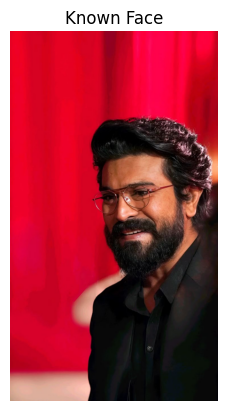

In [5]:
img = cv2.imread(known_image)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.title("Known Face")
plt.show()

In [6]:
uploaded = files.upload()

Saving Ram_Charan_at_Game_Changer_trailer_launch.jpg to Ram_Charan_at_Game_Changer_trailer_launch.jpg


In [11]:
test_image = list(uploaded.keys())[0]
print("Test Image:", test_image)

Test Image: Ram_Charan_at_Game_Changer_trailer_launch.jpg


In [12]:
result = DeepFace.verify(
    img1_path=known_image,
    img2_path=test_image,
    model_name='Facenet'
)

print(result)

{'verified': True, 'distance': 0.371004, 'threshold': 0.4, 'confidence': 51.38, 'model': 'Facenet', 'detector_backend': 'opencv', 'similarity_metric': 'cosine', 'facial_areas': {'img1': {'x': 253, 'y': 437, 'w': 361, 'h': 361, 'left_eye': None, 'right_eye': None}, 'img2': {'x': 78, 'y': 20, 'w': 59, 'h': 59, 'left_eye': None, 'right_eye': None}}, 'time': 0.91}


In [13]:
if result["verified"]:
    print("✅ Same Person Detected")
else:
    print("❌ Different Person")

✅ Same Person Detected


In [14]:
image = cv2.imread(test_image)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    'haarcascade_frontalface_default.xml'
)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30,30)
)

print("Faces Found:", len(faces))

Faces Found: 1


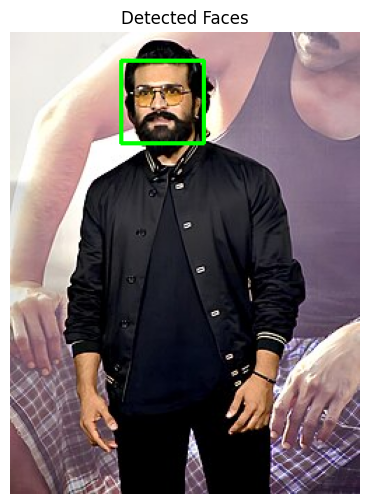

In [15]:
for (x,y,w,h) in faces:
    cv2.rectangle(
        image,
        (x,y),
        (x+w,y+h),
        (0,255,0),
        2
    )

image_rgb = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8,6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Detected Faces")
plt.show()

In [17]:
import os

os.makedirs("dataset/Person1", exist_ok=True)
os.makedirs("dataset/Person2", exist_ok=True)

print("Dataset folders created successfully!")

Dataset folders created successfully!


In [18]:
from google.colab import files

print("Upload images for Person1")
uploaded = files.upload()

Upload images for Person1


Saving 9bb7e1567f5ab2ae2610807ba3c3235a.jpg to 9bb7e1567f5ab2ae2610807ba3c3235a (1).jpg


In [19]:
import shutil

for file_name in uploaded.keys():
    shutil.move(file_name, f"dataset/Person1/{file_name}")

print("Images moved to Person1 folder")

Images moved to Person1 folder


In [20]:
from google.colab import files

print("Upload images for Person2")
uploaded = files.upload()

Upload images for Person2


Saving Ram_Charan_at_Game_Changer_trailer_launch.jpg to Ram_Charan_at_Game_Changer_trailer_launch (1).jpg


In [21]:
import shutil

for file_name in uploaded.keys():
    shutil.move(file_name, f"dataset/Person2/{file_name}")

print("Images moved to Person2 folder")

Images moved to Person2 folder


In [22]:
for root, dirs, files in os.walk("dataset"):
    level = root.replace("dataset", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

dataset/
    Person1/
        9bb7e1567f5ab2ae2610807ba3c3235a (1).jpg
    Person2/
        Ram_Charan_at_Game_Changer_trailer_launch (1).jpg


In [23]:
from deepface import DeepFace
import os

dataset_path = "dataset"

test_img = test_image

best_match = None
best_distance = 999

for person in os.listdir(dataset_path):

    person_folder = os.path.join(
        dataset_path,
        person
    )

    for img in os.listdir(person_folder):

        db_img = os.path.join(
            person_folder,
            img
        )

        try:
            result = DeepFace.verify(
                db_img,
                test_img,
                enforce_detection=False
            )

            if result["distance"] < best_distance:
                best_distance = result["distance"]
                best_match = person

        except:
            pass

print("Recognized Person:", best_match)

26-06-17 06:18:25 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:13<00:00, 44.2MB/s]


Recognized Person: Person2


In [24]:
cv2.imwrite(
    "face_detection_result.jpg",
    image
)

print("Image Saved")

Image Saved


In [27]:
from google.colab import files

files.download(
    "face_detection_result.jpg"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>